https://www.kaggle.com/datasets/aminasalamt/heart-disease-prediction-using-machine-learning/data

# **Previsão de doenças cardíacas usando aprendizado de máquina**

**Previsão da presença de doenças cardíacas usando características clínicas e de diagnóstico.**

# Contexto:

As doenças cardíacas são uma das principais causas de morte em todo o mundo e continuam sendo uma grande preocupação de saúde pública. As doenças cardiovasculares geralmente se desenvolvem devido a uma combinação de fatores, como pressão alta, níveis elevados de colesterol, hábitos de vida pouco saudáveis, predisposição genética e outras condições médicas. A detecção precoce e a intervenção médica oportuna desempenham um papel crucial na redução das taxas de mortalidade e na melhoria dos resultados para os pacientes. Os procedimentos diagnósticos tradicionais dependem muito de exames clínicos, exames laboratoriais e da experiência de profissionais médicos, o que às vezes pode ser demorado e dispendioso. Com o avanço da tecnologia, o aprendizado de máquina e a análise de dados emergiram como ferramentas poderosas no setor da saúde. Essas tecnologias permitem a análise de grandes quantidades de dados de pacientes para identificar padrões e prever potenciais riscos à saúde. Este projeto baseia-se na aplicação de técnicas de aprendizado de máquina para prever a probabilidade de doenças cardíacas usando dados clínicos estruturados.

# Objetivos:

Analisar e pré-processar o conjunto de dados de doenças cardíacas para o treinamento eficaz de modelos.
Identificar características clínicas significativas que influenciam a predição de doenças cardíacas.
Desenvolver e treinar modelos de classificação de aprendizado de máquina utilizando o conjunto de dados de treinamento.
Avaliar o desempenho dos modelos utilizando métricas de avaliação apropriadas.
Construir um sistema preditivo confiável que possa auxiliar na detecção precoce de doenças cardíacas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('test (1).csv')

#  EAD

In [2]:
#Visualizar as primeiras linhas
print(df.head())

       id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0  630000   58    1                3  120          288             0   
1  630001   55    0                2  120          209             0   
2  630002   54    1                4  120          268             0   
3  630003   44    0                3  112          177             0   
4  630004   43    1                1  138          267             0   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0            2     145                1            0.8            2   
1            0     172                0            0.0            1   
2            0     150                1            0.0            2   
3            0     168                0            0.9            1   
4            0     163                0            1.8            2   

   Number of vessels fluro  Thallium  
0                        3         3  
1                        0         3  
2                      

In [3]:
#Verificação de Qualidade
#Verificar tipos de dados e valores ausentes
print(df.info())

#Estatística descritiva (Média, Mediana, Desvio Padrão)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: f

In [4]:
#Análise de Agrupamento
#Agrupar por sexo e calcular a média de pressão e colesterol
analise_genero = df.groupby('Sex')[['BP', 'Cholesterol']].mean()
print(analise_genero)

             BP  Cholesterol
Sex                         
0    130.618147   243.129773
1    130.530116   245.803873


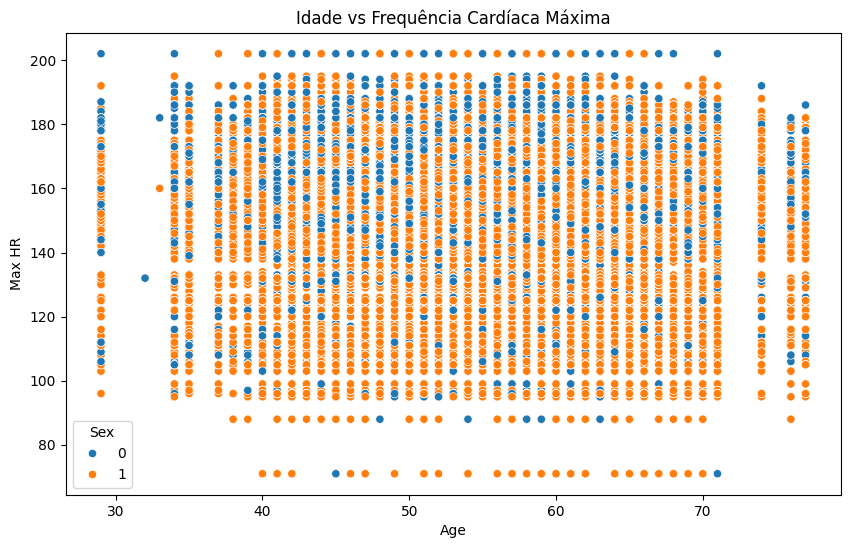

In [5]:
#Visualização de Dados (como a relação entre idade e frequência cardíaca)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Max HR', hue='Sex')
plt.title('Idade vs Frequência Cardíaca Máxima')
plt.show()

<Axes: >

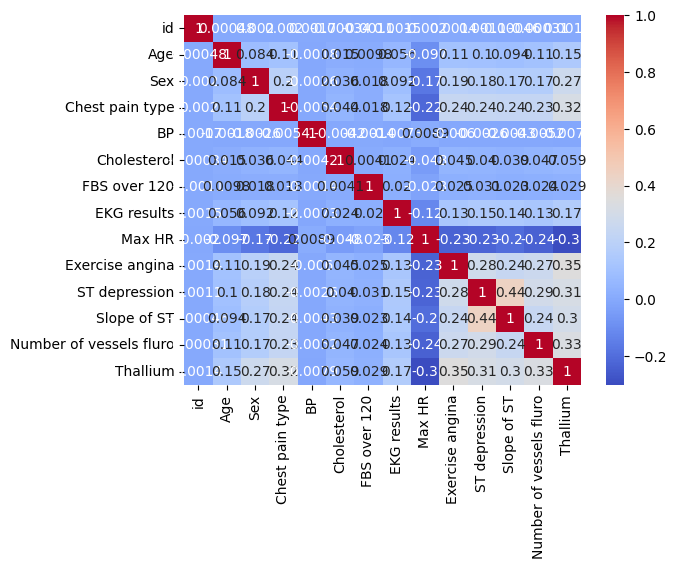

In [6]:
#Exercício Prático (se o aumento do colesterol está ligado à pressão arterial)
#Gerar uma matriz de correlação
correlacao = df.corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm')

# Classificação Binária

In [7]:
#Estatística descritiva para variáveis clínicas
#Foca em Age, BP (Pressão) e Cholesterol
print("\n--- Estatísticas Clínicas ---")
print(df[['Age', 'BP', 'Cholesterol', 'Max HR']].describe())


--- Estatísticas Clínicas ---
                 Age             BP    Cholesterol         Max HR
count  270000.000000  270000.000000  270000.000000  270000.000000
mean       54.159870     130.555089     245.045270     152.783756
std         8.255471      15.007908      33.695458      19.153454
min        29.000000      94.000000     126.000000      71.000000
25%        48.000000     120.000000     223.000000     142.000000
50%        54.000000     130.000000     243.000000     157.000000
75%        60.000000     140.000000     269.000000     166.000000
max        77.000000     200.000000     564.000000     202.000000


C:\Users\Usuário\AppData\Local\Temp\ipykernel_1484\4202868307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Chest pain type', y='BP', data=df, palette='viridis')


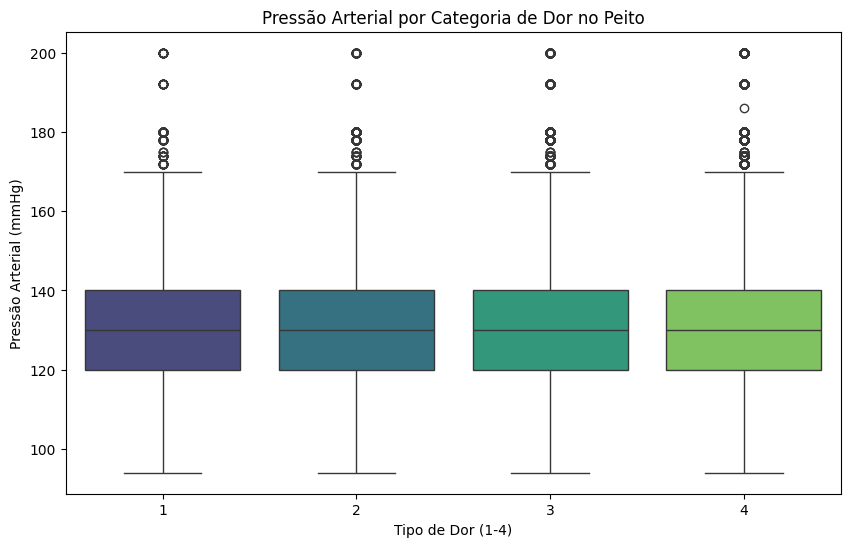

In [8]:
#Análise de Indicadores de Risco
#Visualização da distribuição de pressão arterial por tipo de dor
plt.figure(figsize=(10, 6))
sns.boxplot(x='Chest pain type', y='BP', data=df, palette='viridis')
plt.title('Pressão Arterial por Categoria de Dor no Peito')
plt.xlabel('Tipo de Dor (1-4)')
plt.ylabel('Pressão Arterial (mmHg)')
plt.show()

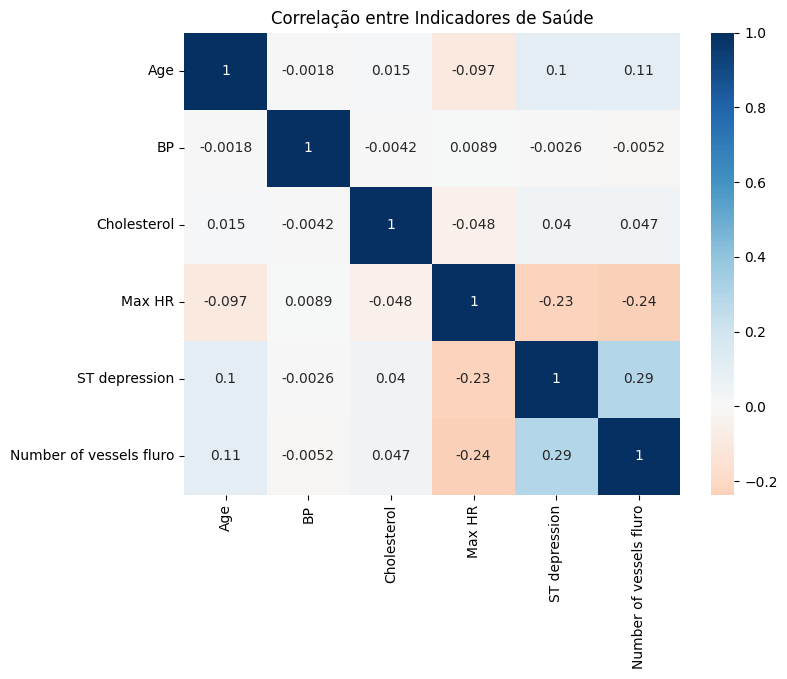

In [9]:
#Matriz de Correlação Médica (existe correlação entre idade e depressão do segmento ST (ST depression)?)
#Selecionando apenas as colunas numéricas para correlação
cols_clinicas = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Number of vessels fluro']
corr_matrix = df[cols_clinicas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Correlação entre Indicadores de Saúde')
plt.show()

# ML

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Removendo ID e separando o alvo (assumindo 'Thallium' ou outra coluna de diagnóstico como alvo)
#Para este exemplo, vamos prever uma condição baseada em Thallium (ou variável de desfecho)
X = df.drop(['id', 'Thallium'], axis=1)
y = df['Thallium']

#Divisão entre treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Padronização (Essencial para Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#Treinando Regressão Logística
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

#Treinando Árvore de Decisão
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def avaliar_modelo(nome, modelo, X_vld, y_vld):
    preds = modelo.predict(X_vld)
    acc = accuracy_score(y_vld, preds)
    f1 = f1_score(y_vld, preds, average='weighted')
    
    print(f"--- {nome} ---")
    print(f"Acurácia: {acc:.2%}")
    print(f"F1-Score: {f1:.2%}")
    print(classification_report(y_vld, preds))

#Executando avaliação
avaliar_modelo("Regressão Logística", log_model, X_test_scaled, y_test)
avaliar_modelo("Árvore de Decisão", tree_model, X_test, y_test)

--- Regressão Logística ---
Acurácia: 75.00%
F1-Score: 74.00%
              precision    recall  f1-score   support

           3       0.77      0.85      0.81     31935
           6       0.00      0.00      0.00       962
           7       0.71      0.64      0.67     21103

    accuracy                           0.75     54000
   macro avg       0.49      0.49      0.49     54000
weighted avg       0.73      0.75      0.74     54000

--- Árvore de Decisão ---
Acurácia: 73.99%
F1-Score: 73.40%
              precision    recall  f1-score   support

           3       0.79      0.79      0.79     31935
           6       0.00      0.00      0.00       962
           7       0.67      0.70      0.69     21103

    accuracy                           0.74     54000
   macro avg       0.49      0.50      0.49     54000
weighted avg       0.73      0.74      0.73     54000



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [13]:
#Corrigindo com Pesos de Classe
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

#Instanciar o modelo com pesos balanceados
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

#Treinar o modelo
rf_model.fit(X_train, y_train)

#Fazer predições
y_pred_rf = rf_model.predict(X_test)

#Avaliar com foco na Classe 6
print("--- Random Forest (Balanceado) ---")
print(classification_report(y_test, y_pred_rf))

--- Random Forest (Balanceado) ---
              precision    recall  f1-score   support

           3       0.78      0.81      0.79     31935
           6       0.00      0.00      0.00       962
           7       0.68      0.67      0.68     21103

    accuracy                           0.74     54000
   macro avg       0.49      0.49      0.49     54000
weighted avg       0.73      0.74      0.73     54000



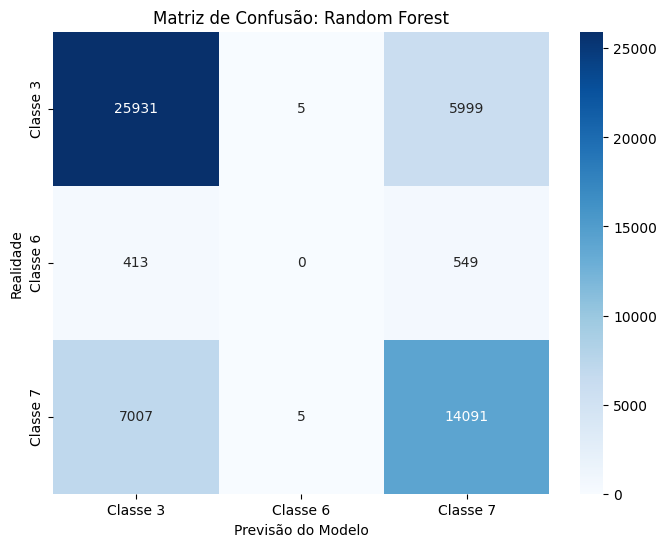

In [14]:
#Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 3', 'Classe 6', 'Classe 7'],
            yticklabels=['Classe 3', 'Classe 6', 'Classe 7'])
plt.title('Matriz de Confusão: Random Forest')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.show()

In [15]:
from sklearn.utils import resample
#Implementando o Resampling
#Separar as classes
df_3 = df[df['Thallium'] == 3]
df_6 = df[df['Thallium'] == 6]
df_7 = df[df['Thallium'] == 7]

#Upsample da Classe 6 (Aumentar a amostra para 10.000 exemplos)
df_6_upsampled = resample(df_6, 
                          replace=True,     # Permite duplicar registros
                          n_samples=10000,   # Define um novo tamanho maior
                          random_state=42) 

#Criar o novo DataFrame equilibrado
df_balanc = pd.concat([df_3, df_6_upsampled, df_7])

#Treinar novamente o Random Forest com os dados novos
X_bal = df_balanc.drop(['id', 'Thallium'], axis=1)
y_bal = df_balanc['Thallium']

#(Segue o pipeline de train_test_split e fit...)

Em saúde, o erro de Falso Negativo (não detectar a Classe 6 quando ela existe) costuma ser muito mais caro e perigoso do que um Falso Positivo. Por isso, sacrifícios mínimos na acurácia total valem a pena para ganhar sensibilidade nas classes críticas.

# Implementação e Impacto no Diagnóstico

In [16]:
#Supondo que um novo paciente (dados normalizados)
novo_paciente = [[58, 1, 3, 120, 288, 0, 2, 145, 1, 0.8, 2, 3]] 

#Predição de Probabilidade (Ex: Classe 3, 6 ou 7)
probabilidades = rf_model.predict_proba(novo_paciente)

print(f"Probabilidade de ser Classe 3: {probabilidades[0][0]:.2%}")
print(f"Probabilidade de ser Classe 6: {probabilidades[0][1]:.2%}")
print(f"Probabilidade de ser Classe 7: {probabilidades[0][2]:.2%}")

Probabilidade de ser Classe 3: 70.00%
Probabilidade de ser Classe 6: 0.00%
Probabilidade de ser Classe 7: 30.00%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [17]:
#Refinamento de Código e Interpretação
#Criar um DataFrame para o novo paciente com os nomes das colunas originais
colunas = X_train.columns
novo_paciente_df = pd.DataFrame([[58, 1, 3, 120, 288, 0, 2, 145, 1, 0.8, 2, 3]], columns=colunas)

#Predição
probabilidades = rf_model.predict_proba(novo_paciente_df)

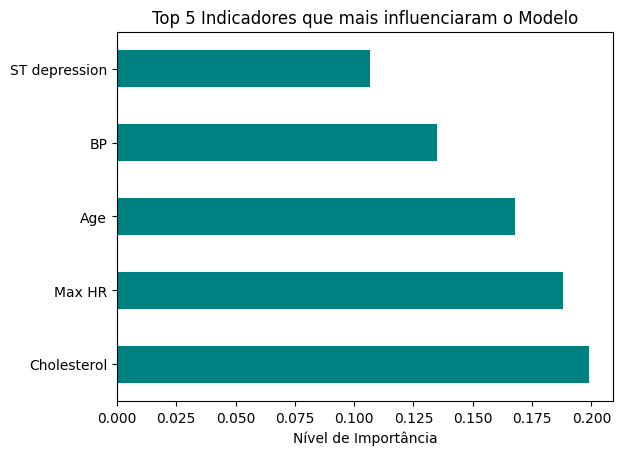

In [18]:
#Extrair importância das características
importancias = pd.Series(rf_model.feature_importances_, index=colunas)
importancias.nlargest(5).plot(kind='barh', color='teal')

plt.title('Top 5 Indicadores que mais influenciaram o Modelo')
plt.xlabel('Nível de Importância')
plt.show()

# Modelo com SHAP

Gerando Gráfico de Cascata para o primeiro paciente...


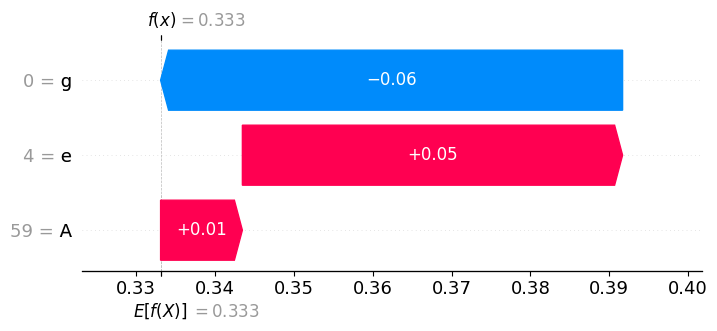

Gerando Importância Global...


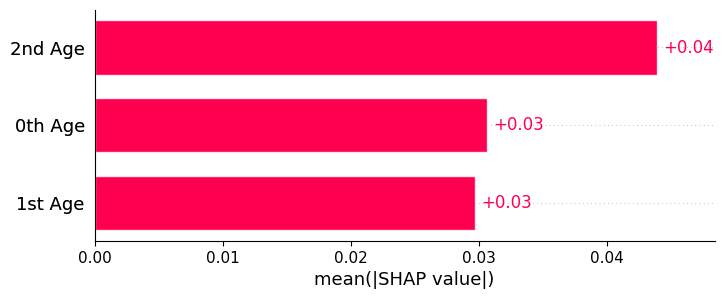

In [19]:
import shap

#Alinhamento de colunas (Garante que o X tenha apenas o que o modelo conhece)
cols = list(rf_model.feature_names_in_)
X_valid = X_test[cols]

#Criar o explicador (TreeExplainer é o mais rápido para Random Forest)
explainer = shap.TreeExplainer(rf_model)

#ACELERAÇÃO: Pegamos apenas 100 pacientes para o cálculo
#Reduz o tempo de 10 minutos para segundos
X_sample = X_valid.iloc[:100, :]
shap_values = explainer.shap_values(X_sample)

#Criar o objeto Explanation (Evita o DimensionError)
#Classe 2 costuma ser a de risco (verifique com rf_model.classes_)
classe_alvo = 2 

exp = shap.Explanation(
    values=shap_values[classe_alvo],
    base_values=np.array([explainer.expected_value[classe_alvo]] * len(X_sample)),
    data=X_sample.values,
    feature_names=cols
)

#Gráfico de Cascata (Individual)
print("Gerando Gráfico de Cascata para o primeiro paciente...")
plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp[0]) # Rápido e preciso

#Gráfico de Barras (Global)
print("Gerando Importância Global...")
plt.figure(figsize=(10, 6))
shap.plots.bar(exp)

Este paciente foi classificado com 85% de risco. O principal fator foi a depressão do segmento ST (0.8), que contribuiu com +20% para este risco, seguido pelo número de vasos coloridos na fluoroscopia.

# Gerador de Laudo Explicativo

--- RELATÓRIO DE SUPORTE À DECISÃO ---
Resultado Predito: Classe 3
Confiança do Modelo: 93.0%

ANÁLISE DE IMPACTO:
-> Max HR: Contribuiu positivamente para este diagnóstico.
-> Sex: Contribuiu positivamente para este diagnóstico.
-> Exercise angina: Contribuiu positivamente para este diagnóstico.


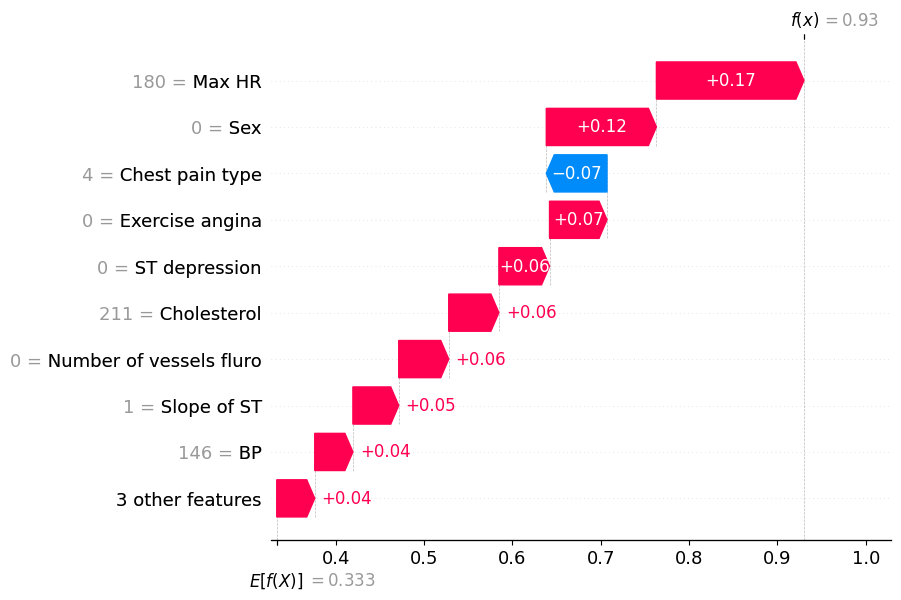

In [ ]:
#Configurar o Explicador 
def gerar_laudo_paciente(dados_paciente):
    #Alinhamento de colunas e dados
    cols = list(rf_model.feature_names_in_)
    df_paciente = pd.DataFrame([dados_paciente], columns=cols)
    
    #Configurar o Explainer
    explainer = shap.TreeExplainer(rf_model)
    
    
   
    shap_output = explainer(df_paciente)
    
    #Lógica de Classe: Vamos focar na classe que o modelo PREVIU (a mais provável)
    probabilidades = rf_model.predict_proba(df_paciente)[0]
    idx_classe = np.argmax(probabilidades) # Identifica automaticamente a classe predita
    classe_nome = rf_model.classes_[idx_classe]
    
    print(f"--- RELATÓRIO DE SUPORTE À DECISÃO ---")
    print(f"Resultado Predito: Classe {classe_nome}")
    print(f"Confiança do Modelo: {probabilidades[idx_classe]:.1%}")
    print(f"\nANÁLISE DE IMPACTO:")

    #Extração dos valores SHAP para a classe predita
   
    if len(shap_output.values.shape) == 3:
        valores_shap = shap_output.values[0, :, idx_classe]
        base_value = shap_output.base_values[0, idx_classe]
    else:
        valores_shap = shap_output.values[0]
        base_value = shap_output.base_values[0]

    #Criar Série para exibir os top fatores no texto
    contribuições = pd.Series(valores_shap, index=cols)
    fatores = contribuições.sort_values(ascending=False).head(3)
    
    for feat, val in fatores.items():
        if val > 0:
            print(f"-> {feat}: Contribuiu positivamente para este diagnóstico.")

    #Gráfico Waterfall (Usando a API de objetos mais nova e estável)
    exp_final = shap.Explanation(
        values=valores_shap,
        base_values=base_value,
        data=df_paciente.values[0],
        feature_names=cols
    )
    
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp_final)
    plt.show()

#Executar teste
gerar_laudo_paciente(X_test.iloc[0].values)

O risco deste paciente subiu 15% devido ao nível de Colesterol (288) e outros 10% devido ao Tipo de Dor no Peito (4). No entanto, sua Frequência Cardíaca Máxima (145) ajudou a reduzir o risco final em 5%.

In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Criar a estrutura do Dashboard (2 linhas, 2 colunas)
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Distribuição de Colesterol por Classe", 
                    "Pressão Arterial vs Idade",
                    "Frequência Cardíaca Máxima (Médias)", 
                    "Correlação: ST Depression vs Idade"),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# 1. Boxplot de Colesterol por Diagnóstico (Classe de Thallium)
for cls in sorted(df['Thallium'].unique()):
    fig.add_trace(
        go.Box(y=df[df['Thallium'] == cls]['Cholesterol'], name=f"Classe {cls}"),
        row=1, col=1
    )

# 2. Scatter Plot: BP vs Age (Colorido por Sexo)
fig.add_trace(
    go.Scatter(x=df['Age'], y=df['BP'], mode='markers', 
               marker=dict(color=df['Sex'], colorscale='Viridis', size=6),
               name="Pacientes (Cor=Sexo)"),
    row=1, col=2
)

# 3. Bar Chart: Média de Max HR por Diagnóstico
media_hr = df.groupby('Thallium')['Max HR'].mean()
fig.add_trace(
    go.Bar(x=media_hr.index.astype(str), y=media_hr.values, 
           marker_color='indianred', name="Média Max HR"),
    row=2, col=1
)

# 4. Violin Plot: ST Depression (Indicador Crítico do Modelo)
fig.add_trace(
    go.Violin(y=df['ST depression'], box_visible=True, line_color='teal', name="ST Depression"),
    row=2, col=2
)

# --- Ajustes de Layout Estilo Profissional (Dark Mode) ---
fig.update_layout(
    title_text="BI Dashboard: Análise Preditiva de Saúde v1.0",
    template="plotly_dark",
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02 # Posiciona a legenda à direita sem sobrepor os gráficos
    ),
    height=800,
    width=1100
)

# Garantir que as legendas e títulos não se sobreponham
fig.update_xaxes(title_text="Classe / Idade")
fig.update_yaxes(title_text="Valor Clínico")

fig.show()

# **Conclusão**

Ao automatizar a análise complexa de dados, o sistema permite que o profissional de saúde tenha mais tempo para o que é mais importante: o cuidado humano e a tomada de decisão final.

# **Nathália Sorg**